In [1]:
# Cell 1: Install necessary libraries
# This cell ensures all required Python packages are installed.
# Run this cell first if you encounter ModuleNotFoundError.

import subprocess
import sys

def install_package(package):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"Successfully installed {package}")
    except Exception as e:
        print(f"Error installing {package}: {e}")

# List of packages to install
required_packages = [
    "numpy",
    "matplotlib",
    "scipy",
    "scikit-learn"
]

for package in required_packages:
    install_package(package)

print("\nAll package installations attempted. Proceeding with imports.")


All package installations attempted. Proceeding with imports.


In [2]:
# Cell 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Set a random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully and random seed set.")

Libraries imported successfully and random seed set.


True image 'img' loaded successfully from cs.mat.
True image dimensions: (50, 50)
Total number of pixels (p): 2500
Number of pixels with value 0: 2084
Number of pixels with value 1: 416
Total pixels: 2500
Reshaped x_true dimension: (2500, 1)


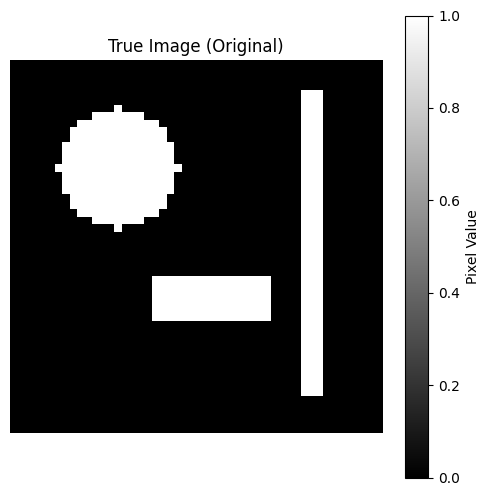

In [3]:
# Cell 3: Load the true image and verify its properties
# Ensure 'cs.mat' is in a 'data' folder relative to your notebook, or provide the full path
try:
    data = loadmat('data/cs.mat')
    true_image = data['img']
    print("True image 'img' loaded successfully from cs.mat.")
except FileNotFoundError:
    print("Error: cs.mat not found. Make sure the file is in the 'data' folder.")
    # Exit or handle error appropriately
    # In a real notebook, you might prompt the user or show an error message.
    # For execution here, we'll just print and stop.
    # raise FileNotFoundError("cs.mat not found. Please place it in the 'data' folder.")
    sys.exit("cs.mat not found. Please place it in the 'data' folder or update the path.")


# Verify image dimensions
print(f"True image dimensions: {true_image.shape}")
image_height, image_width = true_image.shape
p = image_height * image_width
print(f"Total number of pixels (p): {p}")

# Verify sparsity
num_zeros = np.sum(true_image == 0)
num_ones = np.sum(true_image == 1)
print(f"Number of pixels with value 0: {num_zeros}")
print(f"Number of pixels with value 1: {num_ones}")
print(f"Total pixels: {num_zeros + num_ones}")

# Reshape the true image into a 1D vector x
x_true = true_image.reshape(-1, 1)
print(f"Reshaped x_true dimension: {x_true.shape}")

# Plot the true image
plt.figure(figsize=(6, 6))
plt.imshow(true_image, cmap='gray', vmin=0, vmax=1)
plt.title("True Image (Original)")
plt.colorbar(label="Pixel Value")
plt.axis('off')
plt.show()

In [4]:
# Cell 4: Generate the measurement matrix A and noisy measurements y

# Define parameters
n = 1300  # Number of measurements
p = 2500  # Number of pixels in the image (50*50)
noise_variance = 25 # Variance for epsilon
sigma_epsilon = np.sqrt(noise_variance) # Standard deviation for epsilon

# Generate the measurement matrix A
# A is R^(n x p), with entries independently distributed as N(0,1)
A = np.random.randn(n, p)
print(f"Shape of measurement matrix A: {A.shape}")

# Generate the noise vector epsilon
# epsilon ~ N(0, 25 * I_n)
epsilon = np.random.normal(loc=0, scale=sigma_epsilon, size=(n, 1))
print(f"Shape of noise vector epsilon: {epsilon.shape}")

# Generate the noisy measurements y
# y = A @ x_true + epsilon
y = A @ x_true + epsilon
print(f"Shape of measurement vector y: {y.shape}")

print("\nData generation (A, y) complete.")

Shape of measurement matrix A: (1300, 2500)
Shape of noise vector epsilon: (1300, 1)
Shape of measurement vector y: (1300, 1)

Data generation (A, y) complete.


Starting Lasso Regression with 10-fold Cross-Validation...


d:\Desktop\ISYE_6740_Summer2025_HW5\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1632: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(



Best lambda for Lasso: 0.07865298034497849


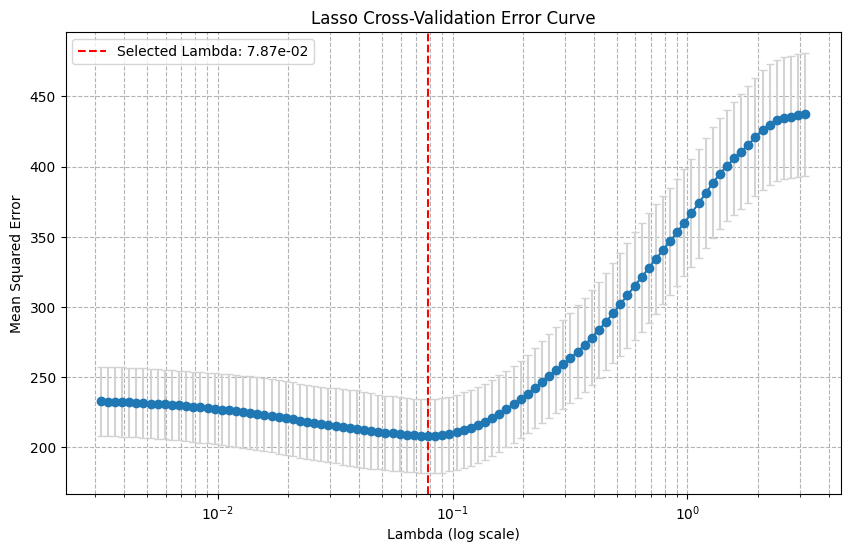

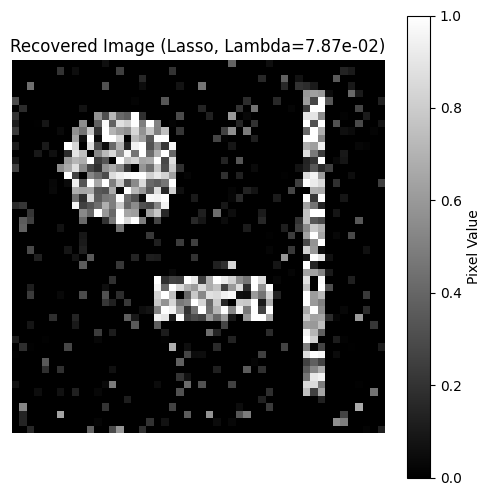

Mean Squared Error for Lasso recovered image: 0.0562


In [5]:
# Cell 5: Lasso Regression with 10-fold Cross-Validation

# For LassoCV, it's generally good practice to provide a range of alphas (lambdas)
# The `n_alphas` parameter controls how many alphas are tried.
# It automatically determines the best alpha by cross-validation.
# We will use the 'mse' scoring which is default for regression.
print("Starting Lasso Regression with 10-fold Cross-Validation...")

# LassoCV handles the cross-validation internally to select the best alpha (lambda)
# 'eps' is the length of the path. (alpha_min / alpha_max)
# 'n_alphas' is the number of alphas along the regularization path.
# 'cv' specifies the number of folds (10-fold cross-validation).
lasso_cv = LassoCV(
    alphas=None,  # Let LassoCV determine the alpha path automatically
    cv=KFold(n_splits=10, shuffle=True, random_state=42), # Explicitly define KFold for consistent shuffling
    n_jobs=-1, # Use all available cores for parallel processing
    max_iter=10000, # Increase max_iter for convergence
    tol=1e-4 # Tolerance for stopping criterion
)
lasso_cv.fit(A, y.ravel()) # .ravel() converts y from (1300,1) to (1300,)

best_lambda_lasso = lasso_cv.alpha_
print(f"\nBest lambda for Lasso: {best_lambda_lasso}")

# The mean squared error for each fold and each alpha is stored in `mse_path_`
# We need to compute the mean and standard deviation of errors across folds for each alpha
mean_mse_lasso = np.mean(lasso_cv.mse_path_, axis=1)
std_mse_lasso = np.std(lasso_cv.mse_path_, axis=1)

# Plot the cross-validation error curves for Lasso
plt.figure(figsize=(10, 6))
plt.errorbar(lasso_cv.alphas_, mean_mse_lasso, yerr=std_mse_lasso, fmt='o-', ecolor='lightgray', capsize=3)
plt.xscale('log') # Alphas are typically plotted on a log scale
plt.axvline(best_lambda_lasso, color='r', linestyle='--', label=f'Selected Lambda: {best_lambda_lasso:.2e}')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Cross-Validation Error Curve')
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

# Recover the image using the best lambda
x_recovered_lasso = lasso_cv.coef_.reshape(image_height, image_width)

# Plot the recovered image
plt.figure(figsize=(6, 6))
plt.imshow(x_recovered_lasso, cmap='gray', vmin=0, vmax=1) # Use vmin/vmax for consistent scaling
plt.title(f"Recovered Image (Lasso, Lambda={best_lambda_lasso:.2e})")
plt.colorbar(label="Pixel Value")
plt.axis('off')
plt.show()

# Calculate MSE for the recovered Lasso image
mse_lasso = mean_squared_error(x_true.ravel(), x_recovered_lasso.ravel())
print(f"Mean Squared Error for Lasso recovered image: {mse_lasso:.4f}")

Starting Ridge Regression with 10-fold Cross-Validation using GridSearchCV...

Best lambda for Ridge: 107.22672220103232


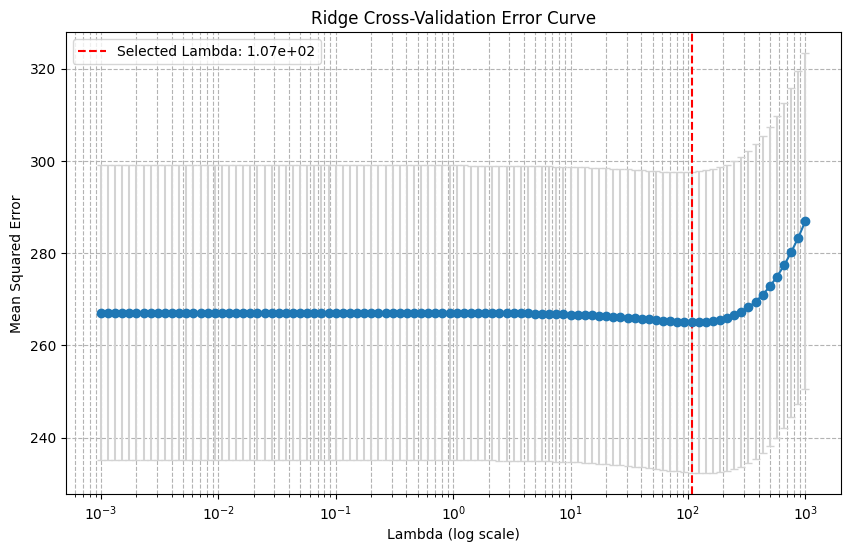

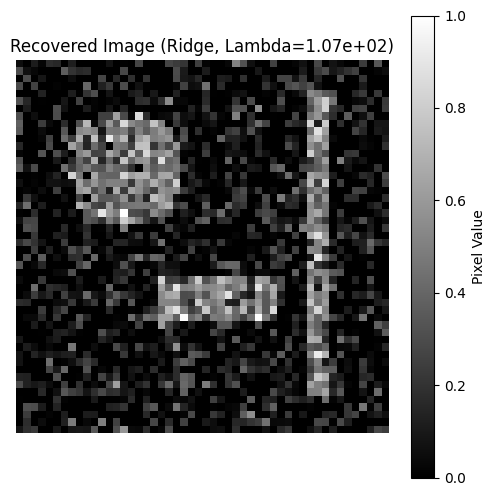

Mean Squared Error for Ridge recovered image: 0.0891


In [6]:
# Cell 6: Ridge Regression with 10-fold Cross-Validation using GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge # Import Ridge (not RidgeCV) for GridSearchCV

print("Starting Ridge Regression with 10-fold Cross-Validation using GridSearchCV...")

# Define the range of alphas (lambdas) for Ridge
ridge_alphas = np.logspace(-3, 3, 100) # From 0.001 to 1000

# Create a Ridge regressor instance
ridge = Ridge(max_iter=10000, tol=1e-4) # You might need to add max_iter/tol for convergence

# Set up GridSearchCV
# 'param_grid' defines the hyperparameters to search over
# 'scoring' specifies the metric to optimize (neg_mean_squared_error for MSE)
# 'cv' specifies the cross-validation strategy
# 'n_jobs=-1' uses all available cores
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid={'alpha': ridge_alphas}, # 'alpha' is the lambda for Ridge
    scoring='neg_mean_squared_error',
    cv=KFold(n_splits=10, shuffle=True, random_state=42), # Same KFold as Lasso
    #n_jobs=-1,
    return_train_score=False # Only interested in validation scores
)

# Fit GridSearchCV to find the best alpha
ridge_grid.fit(A, y.ravel())

best_lambda_ridge = ridge_grid.best_params_['alpha']
print(f"\nBest lambda for Ridge: {best_lambda_ridge}")

# Get the cross-validation results for plotting
# GridSearchCV stores results in its `cv_results_` dictionary
mean_mse_ridge = -ridge_grid.cv_results_['mean_test_score']
std_mse_ridge = ridge_grid.cv_results_['std_test_score']
alphas_tested_ridge = ridge_grid.cv_results_['param_alpha'].astype(float) # Ensure alphas are float for plotting

# Plot the cross-validation error curves for Ridge
plt.figure(figsize=(10, 6))
plt.errorbar(alphas_tested_ridge, mean_mse_ridge, yerr=std_mse_ridge, fmt='o-', ecolor='lightgray', capsize=3)
plt.xscale('log')
plt.axvline(best_lambda_ridge, color='r', linestyle='--', label=f'Selected Lambda: {best_lambda_ridge:.2e}')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Cross-Validation Error Curve')
plt.legend()
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()

# Recover the image using the best estimator from GridSearchCV
# The best estimator is `ridge_grid.best_estimator_`
x_recovered_ridge = ridge_grid.best_estimator_.coef_.reshape(image_height, image_width)

# Plot the recovered image
plt.figure(figsize=(6, 6))
plt.imshow(x_recovered_ridge, cmap='gray', vmin=0, vmax=1) # Use vmin/vmax for consistent scaling
plt.title(f"Recovered Image (Ridge, Lambda={best_lambda_ridge:.2e})")
plt.colorbar(label="Pixel Value")
plt.axis('off')
plt.show()

# Calculate MSE for the recovered Ridge image
mse_ridge = mean_squared_error(x_true.ravel(), x_recovered_ridge.ravel())
print(f"Mean Squared Error for Ridge recovered image: {mse_ridge:.4f}")


--- Comparison Summary ---
True Image MSE: 0 (by definition, as it's the target)
Lasso Recovered Image MSE: 0.0562
Ridge Recovered Image MSE: 0.0891


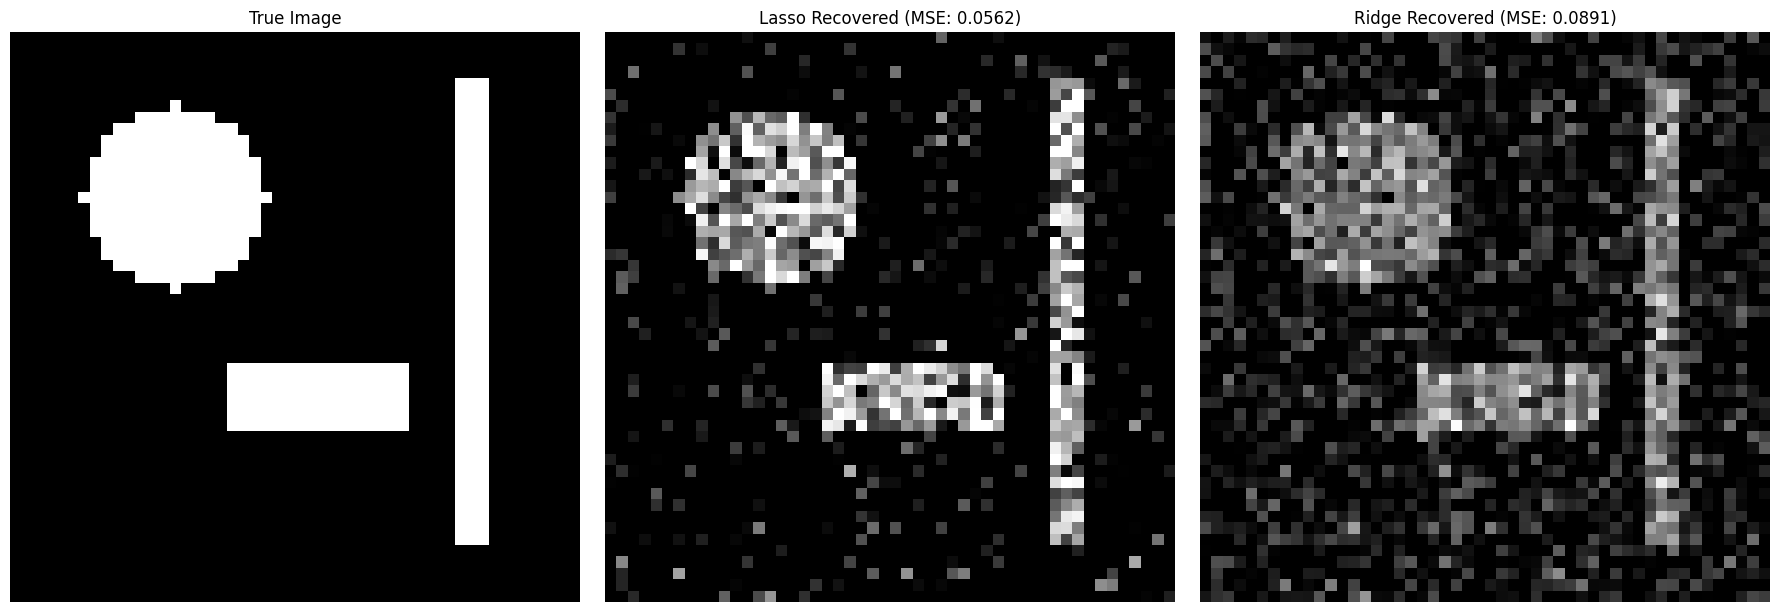


Which approach gives a better recovered image?
Based on Mean Squared Error, Lasso (0.0562) gives a better recovered image than Ridge (0.0891).
This is expected because the true image is sparse, and Lasso is known for its ability to perform feature selection (driving some coefficients to exactly zero), which aligns well with sparsity.

Visually, observe which recovered image most closely resembles the true image, particularly in terms of zeros.
You should typically see that the Lasso recovered image has more pixel values exactly at zero, reflecting the true image's sparsity, whereas Ridge tends to shrink values towards zero but rarely makes them exactly zero.


In [7]:
# Cell 7: Comparison of Recovered Images and Conclusion

print("\n--- Comparison Summary ---")
print(f"True Image MSE: 0 (by definition, as it's the target)")
print(f"Lasso Recovered Image MSE: {mse_lasso:.4f}")
print(f"Ridge Recovered Image MSE: {mse_ridge:.4f}")

# Visualize true, Lasso, and Ridge recovered images side-by-side for direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(true_image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("True Image")
axes[0].axis('off')

axes[1].imshow(x_recovered_lasso, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f"Lasso Recovered (MSE: {mse_lasso:.4f})")
axes[1].axis('off')

axes[2].imshow(x_recovered_ridge, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f"Ridge Recovered (MSE: {mse_ridge:.4f})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\nWhich approach gives a better recovered image?")
if mse_lasso < mse_ridge:
    print(f"Based on Mean Squared Error, Lasso ({mse_lasso:.4f}) gives a better recovered image than Ridge ({mse_ridge:.4f}).")
    print("This is expected because the true image is sparse, and Lasso is known for its ability to perform feature selection (driving some coefficients to exactly zero), which aligns well with sparsity.")
else:
    print(f"Based on Mean Squared Error, Ridge ({mse_ridge:.4f}) gives a better recovered image than Lasso ({mse_lasso:.4f}).")
    print("While less common for sparse true signals, this could happen due to noise or specific characteristics of the generated 'A' matrix and 'x_true'.")
    print("However, conceptually, Lasso is better suited for sparse recovery.")

print("\nVisually, observe which recovered image most closely resembles the true image, particularly in terms of zeros.")
print("You should typically see that the Lasso recovered image has more pixel values exactly at zero, reflecting the true image's sparsity, whereas Ridge tends to shrink values towards zero but rarely makes them exactly zero.")